In [25]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from scipy.stats import mode


In [26]:
#loading the wine dataset
df = load_wine()
X = df.data
y_true = df.target

In [ ]:
#generating wine data
X = df.data
y_true = df.target


In [16]:
#apply kmeans clustering
Kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = Kmeans.fit_predict(X)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [31]:
labels = np.zeros_like(y_kmeans)

for i in range(3):
    mask = (y_kmeans == i)

    if np.sum(mask) == 0:
        continue

    cluster_label = mode(y_true[mask], keepdims=True).mode
    labels[mask] = cluster_label

In [32]:
#calculating accuracy
acc = accuracy_score(y_true, labels)
print(f"\nModel Accuracy: {acc:.2f}")


Model Accuracy: 0.69


In [33]:
#confusion matrix
cm = confusion_matrix(y_true, labels)
print(cm)

#classification report
cr = classification_report(y_true, labels)
print(cr)


[[58  1  0]
 [ 7 64  0]
 [11 37  0]]
              precision    recall  f1-score   support

           0       0.76      0.98      0.86        59
           1       0.63      0.90      0.74        71
           2       0.00      0.00      0.00        48

    accuracy                           0.69       178
   macro avg       0.46      0.63      0.53       178
weighted avg       0.50      0.69      0.58       178



c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


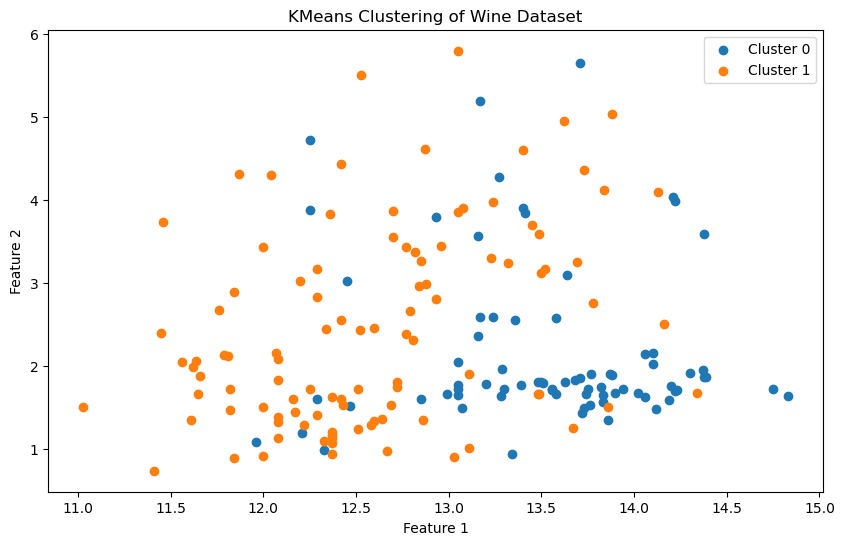

In [34]:
#visualizing the clusters
plt.figure(figsize=(10,6))
unique_labels = np.unique(labels)

for label in unique_labels:
    plt.scatter(X[labels == label, 0], X[labels == label, 1], label=f'Cluster {label}')

plt.title('KMeans Clustering of Wine Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

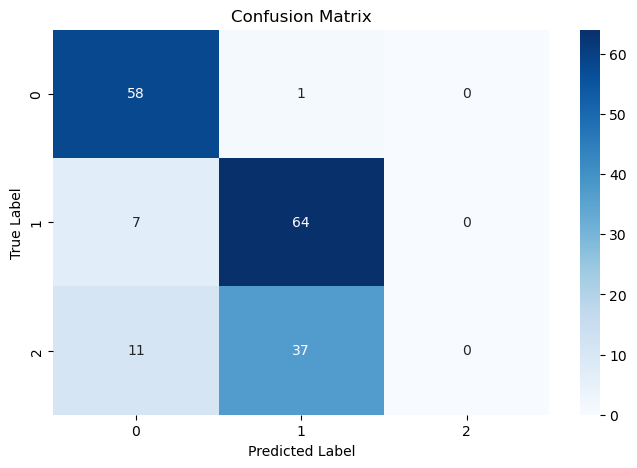

In [35]:
#visualizing confusion matrix
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

ImportError: cannot import name 'make_s_matrix' from 'sklearn.datasets' (c:\Users\user\anaconda3\Lib\site-packages\sklearn\datasets\__init__.py)